# Voronoi / Delaunay

A refresher on two dual partitions of the plane that show up everywhere in
procedural generation: region maps, biome boundaries, organic meshes, road
networks, and natural-looking point relaxation.

**Domain:** Procedural Generation  ·  **recommended addition**  ·  **runnable:** yes

## 1. What & Why

Given a set of **sites** (seed points) in the plane:

- **Voronoi diagram** partitions space into one **cell** per site — every location
  is assigned to its *nearest* site. The cells tile the plane with convex polygons.
- **Delaunay triangulation** is the **dual**: connect two sites with an edge iff
  their Voronoi cells share a border. It triangulates the sites such that no site
  lies inside the *circumcircle* of any triangle (the "empty circumcircle" property),
  which maximizes the minimum angle and avoids sliver triangles.

They are two views of the same structure: the Voronoi diagram is "who owns this
space," the Delaunay triangulation is "who is adjacent to whom."

**Reach for them when** you need:
- **Region/territory maps** — countries, biomes, districts where each cell is one
  area. Voronoi cells are the canonical "organic polygon map" (think Civilization-style
  province maps or the maps in *Polygonal Map Generation* by Amit Patel).
- **Nearest-neighbour structure** — Delaunay edges are a superset of the
  Euclidean minimum spanning tree and nearest-neighbour graph, so they're a great
  scaffold for road networks, rivers, or "connect each thing to its neighbours."
- **Mesh generation** — Delaunay gives well-shaped triangles for terrain or FEM meshes.
- **Point relaxation** — Lloyd's algorithm repeatedly moves each site to its cell's
  centroid, turning a random scatter into an even, blue-noise-like distribution.

**Don't reach for them when** a simple grid or hash works (uniform tiles), or when
you need points on a sphere/manifold (use the spherical variants), or when you only
need spacing (Poisson-disk sampling is simpler — see
[`poisson-disk-sampling`](poisson-disk-sampling.ipynb)).

## 2. Mental Model

**Voronoi = "cell-phone towers."** Drop towers (sites) on a map. Every point in the
country connects to its nearest tower. The coverage areas you get are the Voronoi
cells — borders fall exactly halfway between neighbouring towers (on the
perpendicular bisector).

**Delaunay = "who are my neighbours?"** Draw a line between two towers whenever their
coverage areas touch. That neighbour graph is the Delaunay triangulation.

The two are glued together by a clean geometric fact:

```
   Voronoi vertex  <->  Delaunay triangle   (a vertex sits at the triangle's circumcenter)
   Voronoi edge    <->  Delaunay edge        (they cross at right angles)
   Voronoi cell    <->  Delaunay site/vertex
```

So if you compute one, you essentially have the other. SciPy's `Voronoi` and
`Delaunay` both wrap **Qhull** and expose this duality directly.

## 3. Key Concepts

- **Site / seed / generator** — an input point. One Voronoi cell per site.
- **Cell (Voronoi region)** — the set of all locations closer to this site than to
  any other. Always **convex**. Border-region cells are *unbounded* (open to infinity).
- **Perpendicular bisector** — every Voronoi edge lies on the bisector between two
  neighbouring sites; that's why cells are nearest-neighbour regions.
- **Circumcircle / circumcenter** — the unique circle through a triangle's 3 vertices.
  Its center is a Voronoi vertex. The **empty-circumcircle (Delaunay) property**: no
  site lies strictly inside any triangle's circumcircle.
- **Duality** — Voronoi and Delaunay are dual graphs (see Mental Model).
- **Convex hull** — the Delaunay triangulation's outer boundary is the convex hull of
  the sites; the corresponding Voronoi cells are the unbounded ones.
- **Lloyd relaxation** — iterate: compute Voronoi cells → move each site to its cell
  centroid → repeat. Converges to a **centroidal Voronoi tessellation (CVT)**, an
  even, isotropic layout (kills clumps and gaps).
- **Degeneracy** — 4+ co-circular points or 3 collinear points are ambiguous; Qhull
  handles these with joggling/option flags but they're a classic source of surprises.

## 4. Setup

Pure CPU, tiny data. We use **SciPy** (`scipy.spatial.Voronoi`, `Delaunay`, and their
plot helpers), which wraps the battle-tested **Qhull** library, plus NumPy and
Matplotlib for the figures. Nothing here needs a GPU, network, or API key.

In [1]:
# %pip install scipy numpy matplotlib
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, Delaunay, voronoi_plot_2d, delaunay_plot_2d

rng = np.random.default_rng(7)  # seeded -> deterministic output
print("scipy/qhull ready; numpy", np.__version__)

scipy/qhull ready; numpy 2.4.6


## 5. Worked Examples

### Example 1 — Voronoi & Delaunay from the same points, and their duality

We scatter a handful of sites, build both structures, and verify the key duality fact:
**each finite Voronoi vertex is the circumcenter of a Delaunay triangle.**

In [2]:
pts = rng.random((12, 2))  # 12 sites in the unit square

vor = Voronoi(pts)
tri = Delaunay(pts)

print(f"sites: {len(pts)}")
print(f"Voronoi: {len(vor.vertices)} vertices, {len(vor.ridge_points)} shared borders (Delaunay edges)")
print(f"Delaunay: {tri.simplices.shape[0]} triangles")

# Duality check: circumcenter of each Delaunay triangle == a Voronoi vertex.
def circumcenter(a, b, c):
    ax, ay = a; bx, by = b; cx, cy = c
    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / d
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / d
    return np.array([ux, uy])

ccs = np.array([circumcenter(*pts[s]) for s in tri.simplices])
# Every circumcenter should coincide with some Voronoi vertex.
dists = np.min(np.linalg.norm(vor.vertices[None, :, :] - ccs[:, None, :], axis=2), axis=1)
print(f"max distance circumcenter -> nearest Voronoi vertex: {dists.max():.2e}  (should be ~0)")

sites: 12
Voronoi: 16 vertices, 27 shared borders (Delaunay edges)
Delaunay: 16 triangles
max distance circumcenter -> nearest Voronoi vertex: 5.34e-15  (should be ~0)


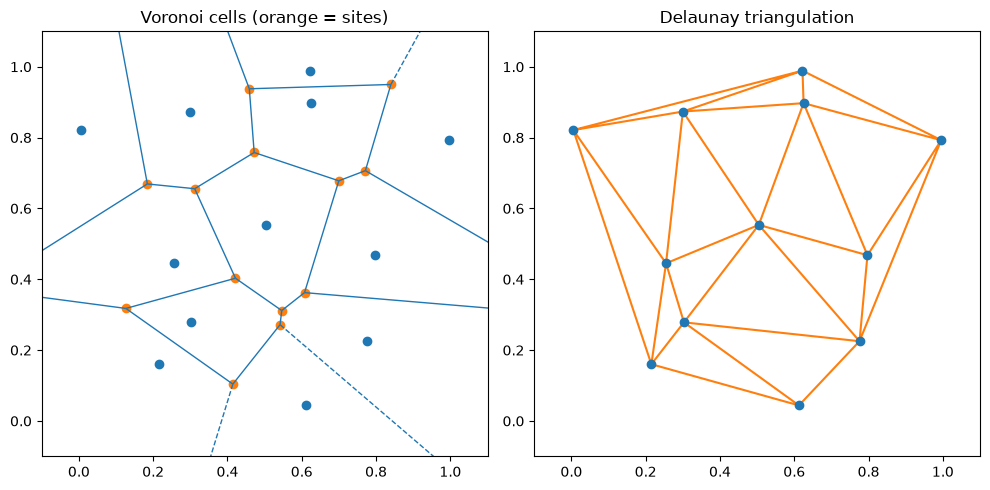

In [3]:
# Render both side by side to *see* the duality.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

voronoi_plot_2d(vor, ax=ax1, show_vertices=True, line_colors="C0", point_size=12)
ax1.set_title("Voronoi cells (orange = sites)")
ax1.set_xlim(-0.1, 1.1); ax1.set_ylim(-0.1, 1.1)

delaunay_plot_2d(tri, ax=ax2)
ax2.set_title("Delaunay triangulation")
ax2.set_xlim(-0.1, 1.1); ax2.set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()

### Example 2 — Lloyd relaxation: turning a random scatter into an even layout

Lloyd's algorithm is the workhorse for *organic-but-even* point distributions in PCG
(city plots, foliage, crater fields). Each step replaces every site with the **centroid
of its Voronoi cell**. We measure the nearest-neighbour spacing and watch its variance
shrink — the points spread out and the clumps disappear.

In [4]:
def polygon_centroid(poly):
    """Area-weighted centroid of a convex polygon (shoelace formula)."""
    x, y = poly[:, 0], poly[:, 1]
    cross = x * np.roll(y, -1) - np.roll(x, -1) * y
    area = cross.sum() / 2.0
    if abs(area) < 1e-12:           # degenerate -> fall back to vertex mean
        return poly.mean(axis=0)
    cx = ((x + np.roll(x, -1)) * cross).sum() / (6 * area)
    cy = ((y + np.roll(y, -1)) * cross).sum() / (6 * area)
    return np.array([cx, cy])

def lloyd_step(points):
    """One Lloyd iteration inside the unit square. Bounded cells move to their
    centroid (clipped to the box); unbounded (edge) cells stay put."""
    v = Voronoi(points)
    new = points.copy()
    for i, reg_idx in enumerate(v.point_region):
        region = v.regions[reg_idx]
        if not region or -1 in region:      # unbounded cell -> leave the site
            continue
        poly = v.vertices[region]
        c = polygon_centroid(poly)
        new[i] = np.clip(c, 0.0, 1.0)
    return new

def min_neighbor_dists(points):
    from scipy.spatial import cKDTree
    d, _ = cKDTree(points).query(points, k=2)
    return d[:, 1]  # distance to nearest *other* point

P = rng.random((60, 2))
for step in range(6):
    nn = min_neighbor_dists(P)
    print(f"iter {step}: mean NN spacing {nn.mean():.4f}  std {nn.std():.4f}  (lower std = more even)")
    P = lloyd_step(P)
nn = min_neighbor_dists(P)
print(f"final : mean NN spacing {nn.mean():.4f}  std {nn.std():.4f}")

iter 0: mean NN spacing 0.0669  std 0.0371  (lower std = more even)
iter 1: mean NN spacing 0.0972  std 0.0296  (lower std = more even)
iter 2: mean NN spacing 0.1113  std 0.0262  (lower std = more even)
iter 3: mean NN spacing 0.1158  std 0.0253  (lower std = more even)
iter 4: mean NN spacing 0.1200  std 0.0270  (lower std = more even)
iter 5: mean NN spacing 0.1241  std 0.0260  (lower std = more even)
final : mean NN spacing 0.1255  std 0.0250


The standard deviation of nearest-neighbour spacing drops sharply over a few
iterations: that falling variance *is* the clumps and gaps being smoothed into an
even, blue-noise-like field — exactly what you want for natural-looking scatter.

## 6. Gotchas & Pitfalls

- **Unbounded cells are real.** Sites on the convex hull have cells that extend to
  infinity. In SciPy these regions contain a `-1` vertex index and `vor.vertices`
  doesn't include the points at infinity. You **must** clip cells to a bounding box
  (or add far-away "guard" points around your domain) before you can fill/area them.
- **`vor.regions` vs `vor.point_region`.** `regions` is *not* in site order. Map a site
  `i` to its region with `vor.regions[vor.point_region[i]]`. Getting this wrong silently
  pairs sites with the wrong polygons.
- **Empty region.** `vor.regions` usually contains one empty `[]` entry — skip it.
- **Degenerate inputs.** Duplicate points, perfectly collinear points, or many
  co-circular points (e.g. a regular grid) make the triangulation ambiguous and Qhull
  may error. Add a tiny jitter, or pass Qhull options (`qhull_options="QJ"` to joggle).
- **It's planar (R²/R³), Euclidean, and convex-hull-bounded.** No built-in support for
  toroidal/wrap-around worlds, geodesic (sphere) distance, or non-Euclidean metrics —
  you tile/duplicate points or use a specialized library for those.
- **Lloyd needs bounded cells.** Relaxing edge sites by their (infinite) centroid is
  undefined; clip to the domain or hold hull sites fixed, or all your points drift inward.
- **Cost.** Construction is O(n log n), but recomputing Voronoi every Lloyd iteration
  over large n adds up. For tens of thousands of points, batch and reuse.

## 7. When to Use vs Alternatives

| Need | Use this | Instead of |
|------|----------|------------|
| Organic region/territory map (one polygon per seed) | **Voronoi** | square/hex grid (looks artificial) |
| Adjacency / neighbour graph, road & river skeletons | **Delaunay** (superset of EMST & NN-graph) | brute-force all-pairs distances |
| Even, no-clump point scatter | **Lloyd relaxation** on Voronoi | rejection sampling |
| Just spacing, don't need cells/adjacency | **Poisson-disk sampling** (simpler, faster) | Voronoi + Lloyd |
| Well-shaped triangle mesh for terrain/FEM | **Delaunay** | naive fan/grid triangulation (slivers) |
| Points on a sphere / globe | spherical Voronoi (`SphericalVoronoi`) | planar Voronoi (wrong near poles) |
| Uniform tiles, cheap lookup | **grid / spatial hash** | Voronoi (overkill) |

Rules of thumb:
- **Voronoi vs grid:** grids are cheaper and trivially indexable; Voronoi buys you
  *organic* irregular cells at the cost of needing real geometry (clipping, polygon ops).
- **Voronoi+Lloyd vs Poisson-disk:** both give blue-noise-ish spacing. Poisson-disk is
  simpler and gives a hard minimum distance; Voronoi+Lloyd additionally hands you the
  cell polygons and adjacency for free, so prefer it when you need the *map*, not just
  the points. See [`poisson-disk-sampling`](poisson-disk-sampling.ipynb).
- **Delaunay vs a full graph:** Delaunay is the sweet spot for "connect to neighbours"
  — sparse (O(n) edges), planar, and contains the MST, so pathfinding/road graphs built
  on it look natural without an O(n²) edge explosion.

## 8. Resources

- **SciPy spatial docs** — `Voronoi`, `Delaunay`, `voronoi_plot_2d`, `delaunay_plot_2d`:
  https://docs.scipy.org/doc/scipy/reference/spatial.html
- **Qhull** (the engine SciPy wraps; the authority on options & degeneracy handling):
  http://www.qhull.org/
- **Amit Patel — "Polygonal Map Generation for Games"** (the canonical Voronoi-for-PCG
  tutorial; biomes, rivers, coastlines): https://www.redblobgames.com/maps/mapgen2/
- **Lloyd's algorithm / centroidal Voronoi tessellation** (overview & convergence):
  https://en.wikipedia.org/wiki/Lloyd%27s_algorithm
- **"Computational Geometry: Algorithms and Applications"** (de Berg et al.) — the
  textbook treatment of Voronoi/Delaunay and the empty-circumcircle property.